In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [3]:
df=pd.read_csv("ev_vehicle_battery_preprocessed_dataset.csv")

In [4]:
df.shape

(8554, 12)

In [5]:
df.isnull().sum()

Car_Model                  0
Battery_Type               0
Battery_Capacity_kWh       0
Vehicle_Age_Months         0
Total_Charging_Cycles      0
Avg_Temperature_C          0
Fast_Charge_Ratio          0
Avg_Discharge_Rate_C       0
Driving_Style              0
Internal_Resistance_Ohm    0
SoH_Percent                0
Battery_Status             0
dtype: int64

In [6]:
df.describe()

,Battery_Capacity_kWh,Vehicle_Age_Months,Total_Charging_Cycles,Avg_Temperature_C,Fast_Charge_Ratio,Avg_Discharge_Rate_C,Internal_Resistance_Ohm,SoH_Percent
count,8554.000000,8554.000000,8554.000000,8554.000000,8554.000000,8554.000000,8554.000000,8554.000000
mean,64.980360,64.907061,828.407996,32.057605,0.648233,2.005784,0.049354,73.850545
std,20.234249,30.435006,542.718981,10.405582,0.277556,0.778442,0.030473,19.978250
min,26.000000,1.000000,4.000000,-12.900000,0.000000,0.500000,0.010000,35.010000
25%,60.000000,44.000000,359.250000,24.200000,0.450000,1.400000,0.026000,54.862500
50%,72.000000,66.000000,798.000000,32.090000,0.741000,2.020000,0.039000,82.920000
75%,75.000000,87.000000,1221.000000,40.400000,0.861000,2.500000,0.072000,90.480000
max,88.000000,119.000000,1998.000000,53.600000,1.000000,3.500000,0.120000,98.000000


In [7]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8554 entries, 0 to 8553
Data columns (total 12 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   Car_Model                8554 non-null   object 
 1   Battery_Type             8554 non-null   object 
 2   Battery_Capacity_kWh     8554 non-null   int64  
 3   Vehicle_Age_Months       8554 non-null   float64
 4   Total_Charging_Cycles    8554 non-null   float64
 5   Avg_Temperature_C        8554 non-null   float64
 6   Fast_Charge_Ratio        8554 non-null   float64
 7   Avg_Discharge_Rate_C     8554 non-null   float64
 8   Driving_Style            8554 non-null   object 
 9   Internal_Resistance_Ohm  8554 non-null   float64
 10  SoH_Percent              8554 non-null   float64
 11  Battery_Status           8554 non-null   object 
dtypes: float64(7), int64(1), object(4)
memory usage: 802.1+ KB


histograms

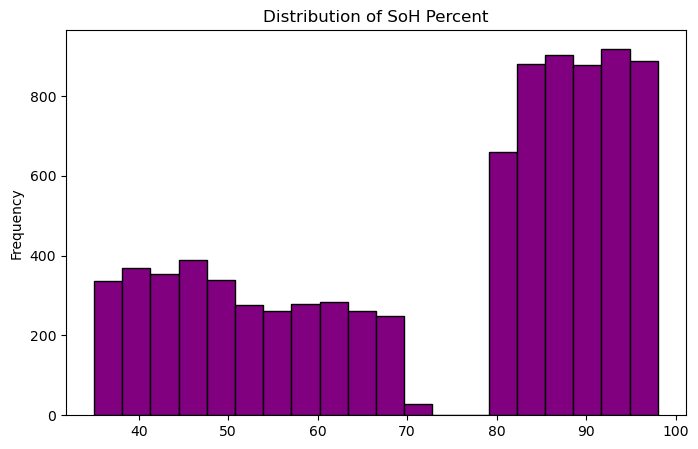

In [8]:

df['SoH_Percent'].plot(kind='hist', bins=20, color="purple", edgecolor="black" ,figsize=(8,5), title='Distribution of SoH Percent')
plt.show()

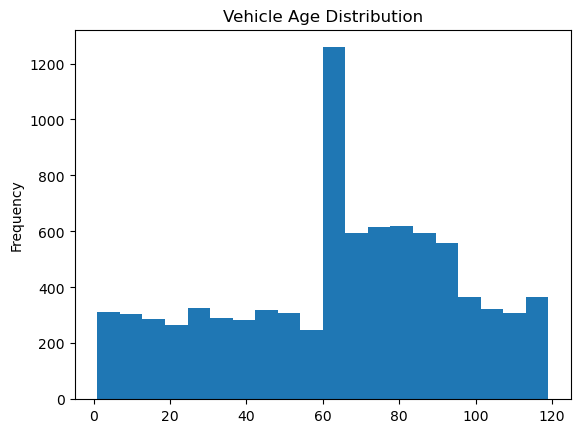

In [9]:
df["Vehicle_Age_Months"].plot(kind="hist", bins=20)
plt.title("Vehicle Age Distribution")
plt.show()

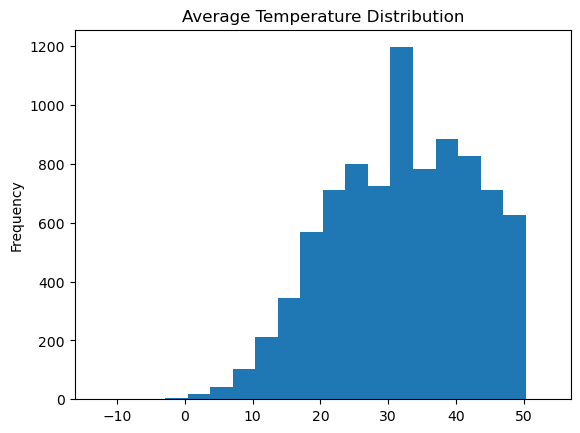

In [10]:
df['Avg_Temperature_C'].plot(kind='hist', bins=20, title='Average Temperature Distribution')
plt.show()

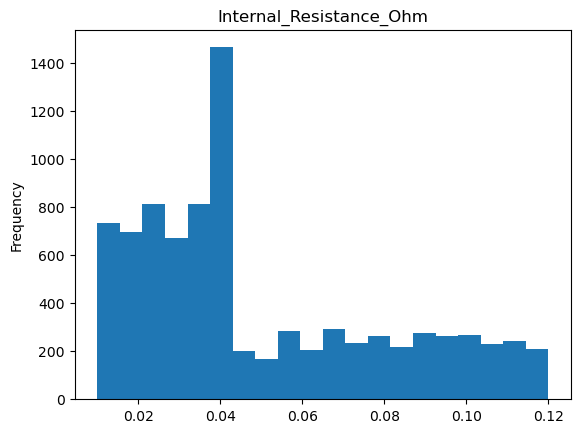

In [11]:
df["Internal_Resistance_Ohm"].plot(kind="hist", bins=20)
plt.title("Internal_Resistance_Ohm")
plt.show()

bar graphs

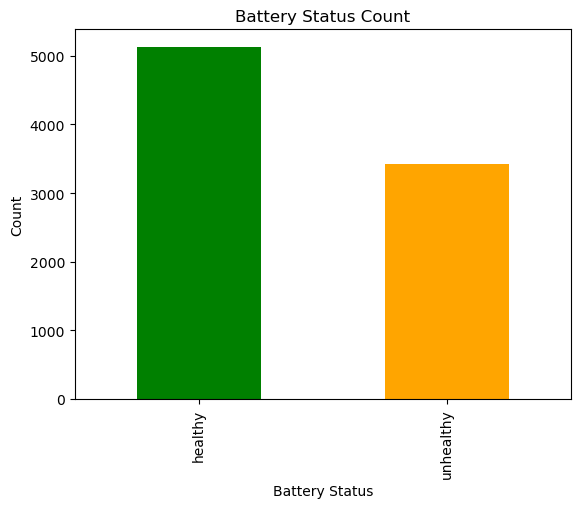

In [12]:

df["Battery_Status"].value_counts().plot(
    kind="bar",
    color=["green", "orange", "red"]
)
plt.title("Battery Status Count")
plt.xlabel("Battery Status")
plt.ylabel("Count")
plt.show()

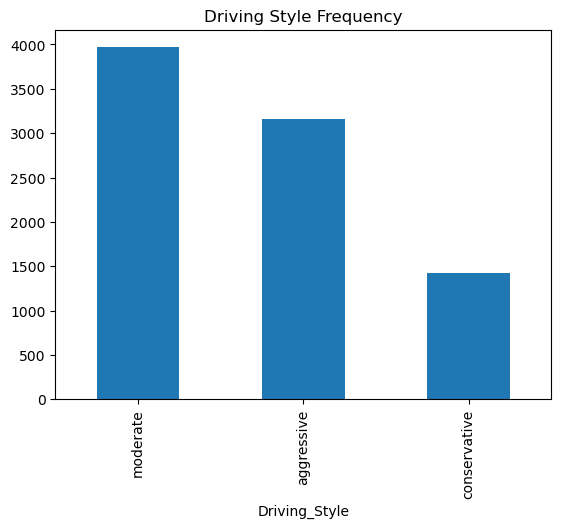

In [13]:
df["Driving_Style"].value_counts().plot(kind="bar")
plt.title("Driving Style Frequency")
plt.show()

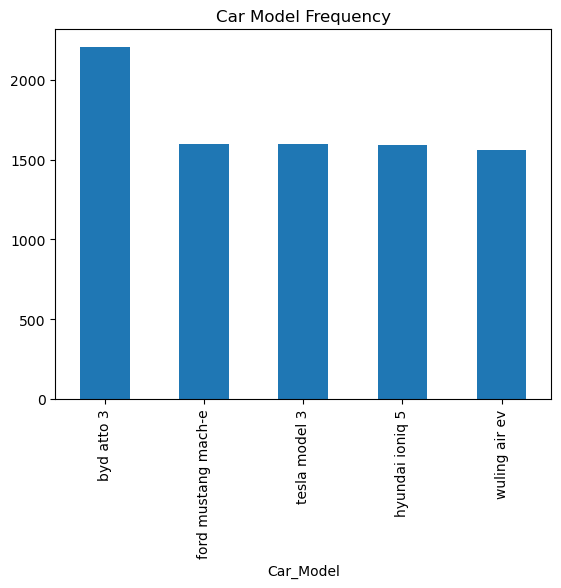

In [14]:
df["Car_Model"].value_counts().plot(kind="bar")
plt.title("Car Model Frequency")
plt.show()

line graph

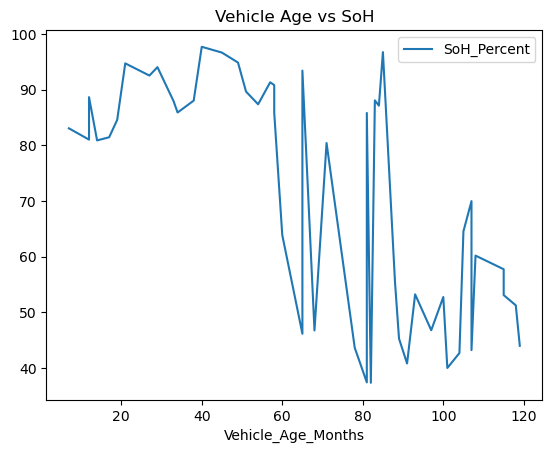

In [23]:
df.head(50).sort_values("Vehicle_Age_Months").plot(
    x="Vehicle_Age_Months", 
    y="SoH_Percent", 
    kind="line"
)
plt.title("Vehicle Age vs SoH")
plt.show()

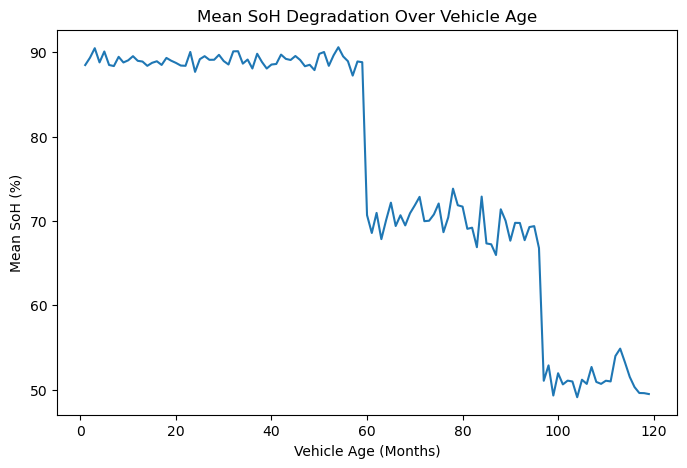

In [17]:
df.groupby("Vehicle_Age_Months")["SoH_Percent"].mean().plot(kind="line", figsize=(8,5))
plt.xlabel("Vehicle Age (Months)")
plt.ylabel("Mean SoH (%)")
plt.title("Mean SoH Degradation Over Vehicle Age")
plt.show()

scatter graph

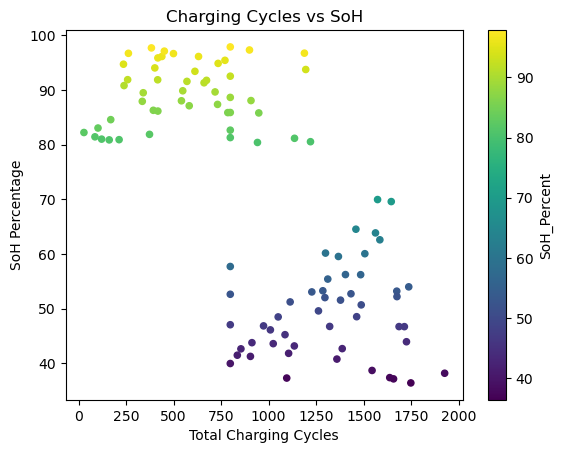

In [24]:

df.head(100).plot(
    kind="scatter",
    x="Total_Charging_Cycles",
    y="SoH_Percent",
    c="SoH_Percent",
    cmap="viridis"
)

plt.title("Charging Cycles vs SoH")
plt.xlabel("Total Charging Cycles")
plt.ylabel("SoH Percentage")
plt.show()

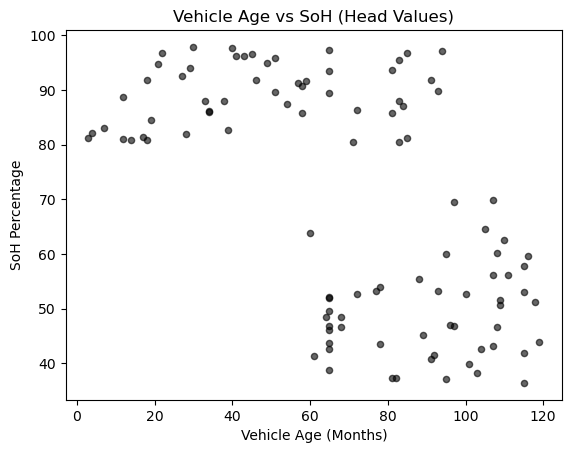

In [25]:

df.head(100).plot(
    kind="scatter",
    x="Vehicle_Age_Months",
    y="SoH_Percent",
    color="black",
    alpha=0.6
)

plt.title("Vehicle Age vs SoH (Head Values)")
plt.xlabel("Vehicle Age (Months)")
plt.ylabel("SoH Percentage")
plt.show()

pie charts

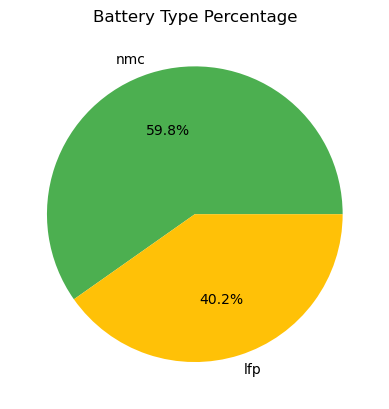

In [26]:
df["Battery_Type"].value_counts().plot(
    kind="pie",
    autopct="%1.1f%%",
    colors=["#4CAF50", "#FFC107"]
)

plt.title("Battery Type Percentage")
plt.ylabel("")
plt.show()

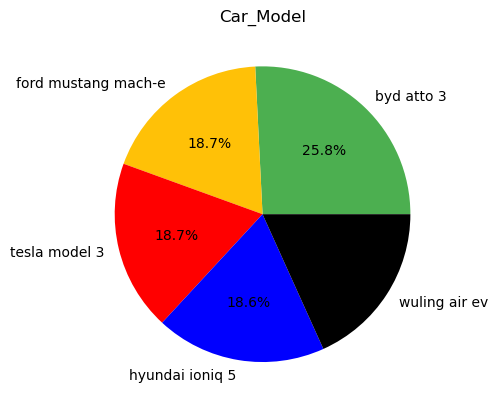

In [27]:
df["Car_Model"].value_counts().plot(
    kind="pie",
    autopct="%1.1f%%",
    colors=["#4CAF50", "#FFC107",'red','blue','black']
)
plt.title("Car_Model")
plt.ylabel("")
plt.show()

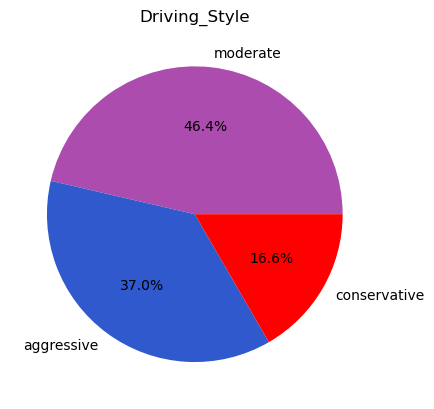

In [28]:
df["Driving_Style"].value_counts().plot(
    kind="pie",
    autopct="%1.1f%%",
    colors=["#AC4CAF", "#2F59CC","red"]
)
plt.title("Driving_Style")
plt.ylabel("")
plt.show()

Box plots

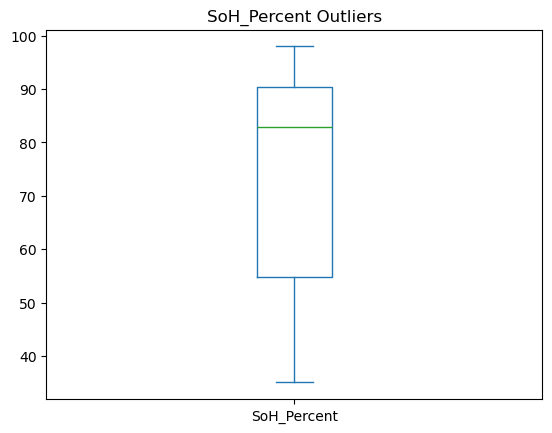

In [29]:
df['SoH_Percent'].plot(kind='box', title='SoH_Percent Outliers')
plt.show()

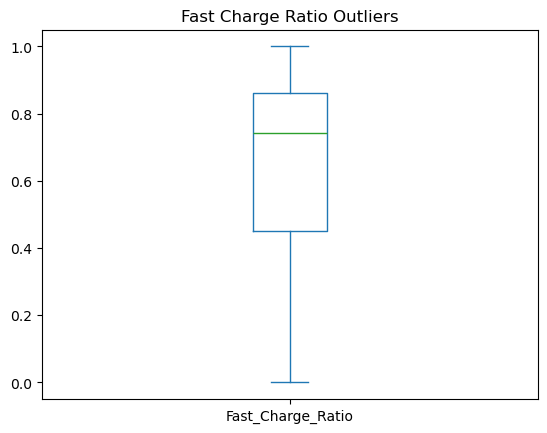

In [31]:
df['Fast_Charge_Ratio'].plot(kind='box', title='Fast Charge Ratio Outliers')
plt.show()

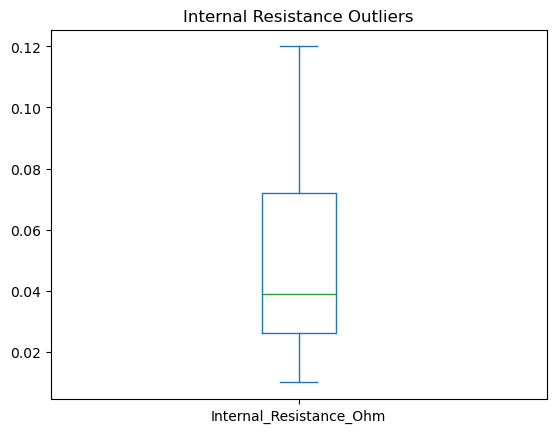

In [32]:
df['Internal_Resistance_Ohm'].plot(kind='box', title='Internal Resistance Outliers')
plt.show()

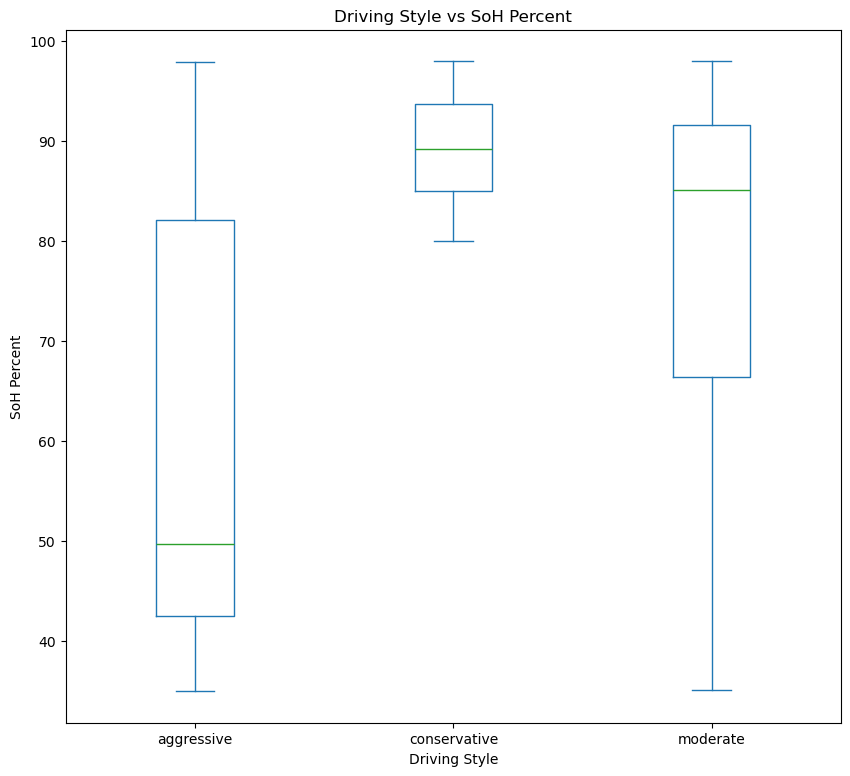

In [40]:

df.plot(
    kind="box",
    column="SoH_Percent",
    by="Driving_Style"
)

plt.title("Driving Style vs SoH Percent")
plt.suptitle("")
plt.xlabel("Driving Style")
plt.ylabel("SoH Percent")
plt.show()

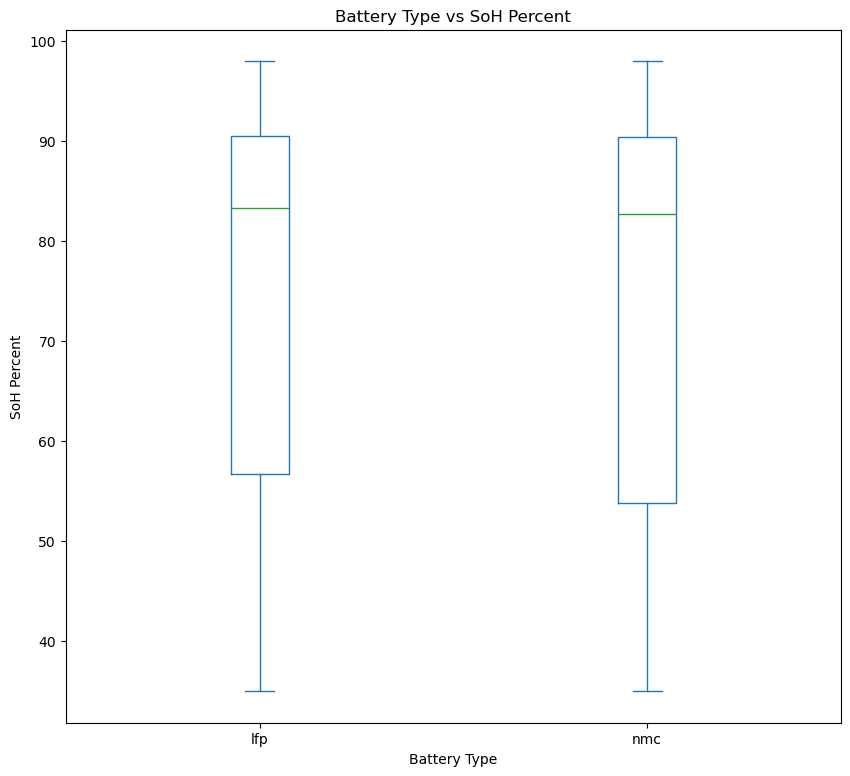

In [ ]:
df.plot(
    kind="box",
    column="SoH_Percent",
    by="Battery_Type"
)
plt.title("Battery Type vs SoH Percent")
plt.suptitle("")
plt.xlabel("Battery Type")
plt.ylabel("SoH Percent")
plt.show()

Area plots


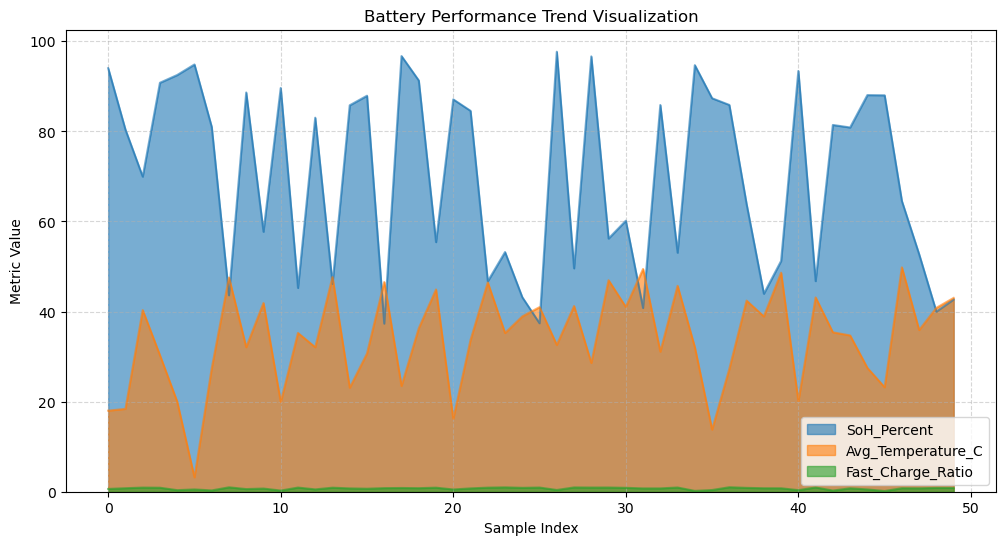

In [29]:
cols_for_area = [
    "SoH_Percent",
    "Avg_Temperature_C",
    "Fast_Charge_Ratio"
]
df_area = df[cols_for_area].copy()
df_subset = df_area.head(50)
for col in df_subset.columns:
    if df_subset[col].min() < 0:
        df_subset[col] = df_subset[col] - df_subset[col].min()
df_subset.plot(
    kind="area",
    alpha=0.6,
    stacked=False,
    figsize=(12,6)
)
plt.title("Battery Performance Trend Visualization")
plt.xlabel("Sample Index")
plt.ylabel("Metric Value")
plt.grid(True, linestyle='--', alpha=0.5)

plt.show()

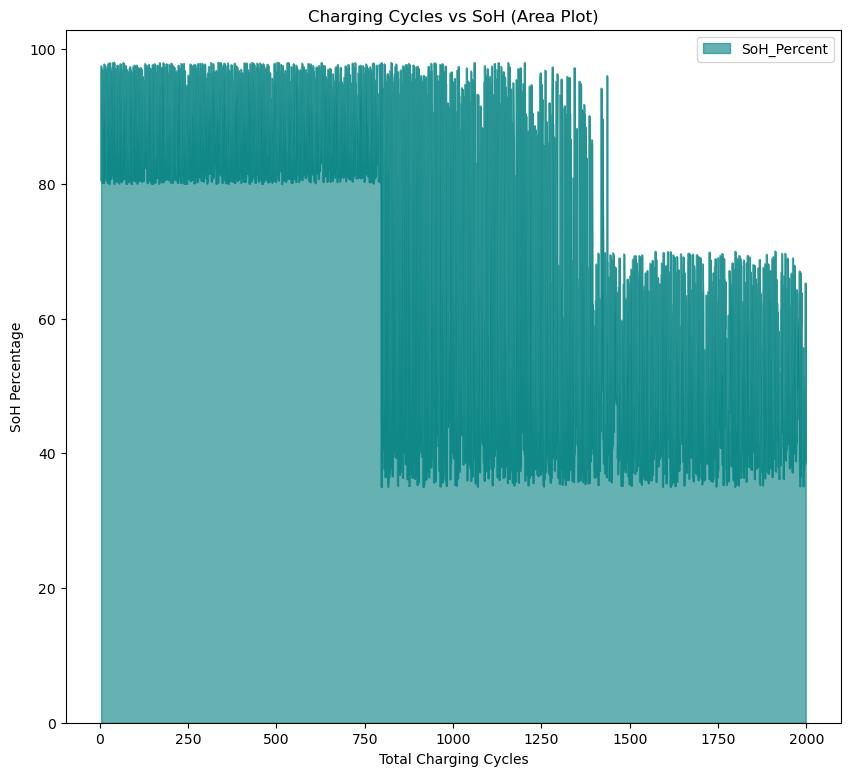

In [42]:
df_sorted_cycles = df.sort_values("Total_Charging_Cycles")

df_sorted_cycles.plot(
    x="Total_Charging_Cycles",
    y="SoH_Percent",
    kind="area",
    alpha=0.6,
    color="teal"
)

plt.title("Charging Cycles vs SoH (Area Plot)")
plt.xlabel("Total Charging Cycles")
plt.ylabel("SoH Percentage")
plt.show()

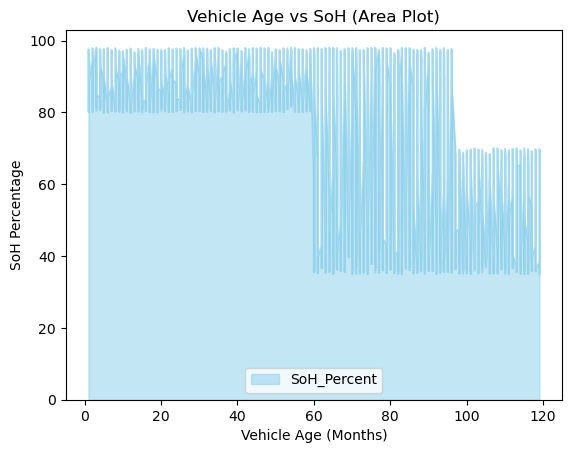

In [31]:
df_sorted = df.sort_values("Vehicle_Age_Months")

df_sorted.plot(
    x="Vehicle_Age_Months",
    y="SoH_Percent",
    kind="area",
    alpha=0.5,
    color="skyblue"
)

plt.title("Vehicle Age vs SoH (Area Plot)")
plt.xlabel("Vehicle Age (Months)")
plt.ylabel("SoH Percentage")
plt.show()

In [ ]:
pip install pywaffle

Note: you may need to restart the kernel to use updated packages.


Waffle charts

In [55]:
from pywaffle import Waffle
import matplotlib.pyplot as plt

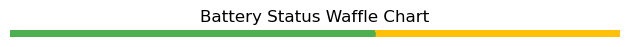

In [64]:
status_counts = df["Battery_Status"].value_counts()


fig = plt.figure(
    FigureClass=Waffle,
    rows=10,
    values=status_counts,
    colors=["#4CAF50", "#FFC107"],
    title={'label': 'Battery Status Waffle Chart', 'loc': 'center'}
)

plt.show()

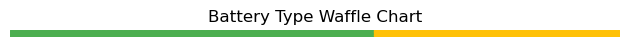

In [63]:
status_counts = df["Battery_Type"].value_counts()


fig = plt.figure(
    FigureClass=Waffle,
    rows=10,
    values=status_counts,
    colors=["#4CAF50", "#FFC107"],
    title={'label': 'Battery Type Waffle Chart', 'loc': 'center'}
)

plt.show()

In [25]:
pip install wordcloud

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 526.2/526.2 kB 310.1 kB/s  0:00:030:00:01m
Note: you may need to restart the kernel to use updated packages.


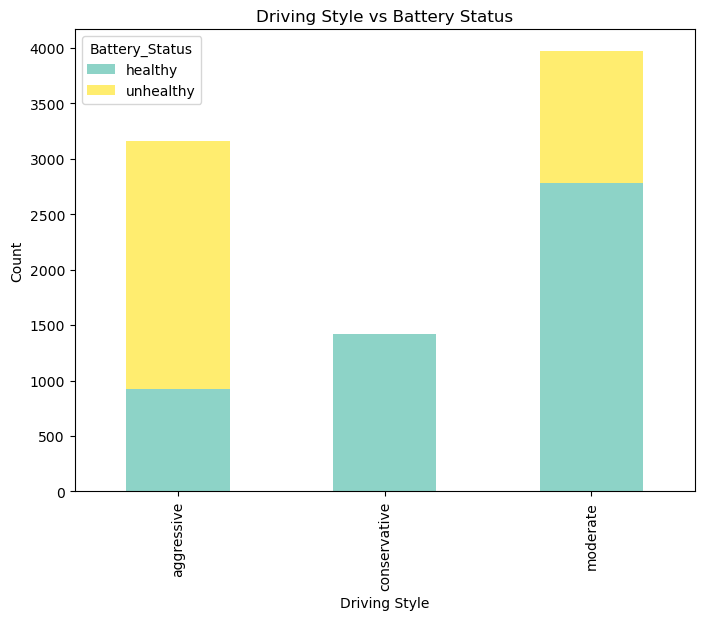

In [43]:
status_style = pd.crosstab(df["Driving_Style"], df["Battery_Status"])

status_style.plot(
    kind="bar",
    stacked=True,
    figsize=(8,6),
    colormap="Set3"
)

plt.title("Driving Style vs Battery Status")
plt.xlabel("Driving Style")
plt.ylabel("Count")
plt.show()

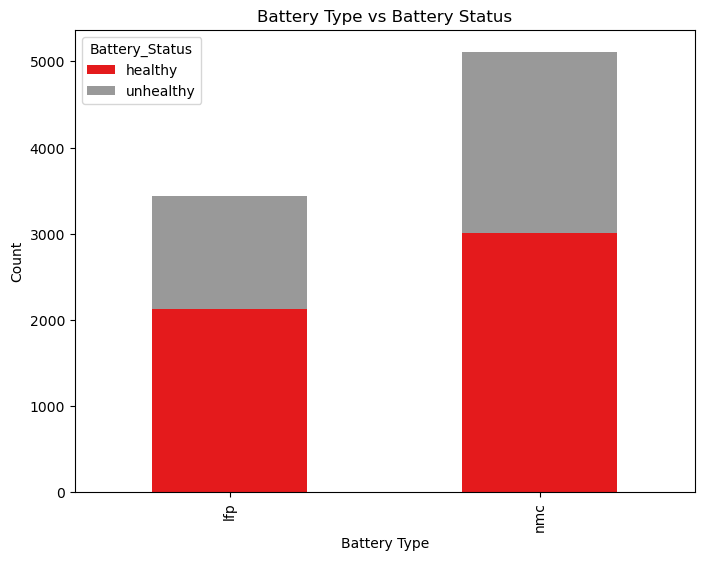

In [46]:
status_style = pd.crosstab(df["Battery_Type"], df["Battery_Status"])

status_style.plot(
    kind="bar",
    stacked=True,
    figsize=(8,6),
    colormap="Set1"
)

plt.title("Battery Type vs Battery Status")
plt.xlabel("Battery Type")
plt.ylabel("Count")
plt.show()

In [35]:
pip install seaborn

Note: you may need to restart the kernel to use updated packages.


In [6]:
pip install wordcloud

Note: you may need to restart the kernel to use updated packages.


In [7]:
from wordcloud import WordCloud, STOPWORDS

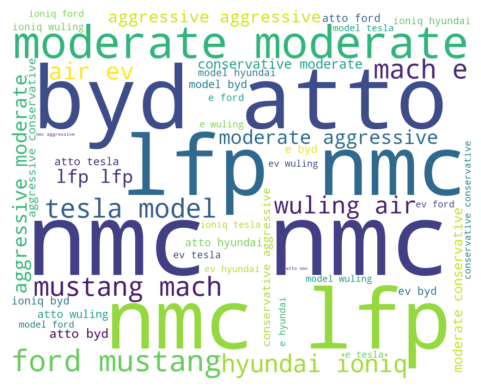

In [ ]:
from wordcloud import WordCloud
import matplotlib.pyplot as plt

text = " ".join(df['Car_Model'].astype(str)) + " " + \
       " ".join(df['Battery_Type'].astype(str)) + " " + \
       " ".join(df['Driving_Style'].astype(str))
alice_wc = WordCloud(width=1000, height=800, background_color='white').generate(text)
fig = plt.figure()
plt.imshow(alice_wc, interpolation='bilinear')
plt.axis('off')
plt.show()

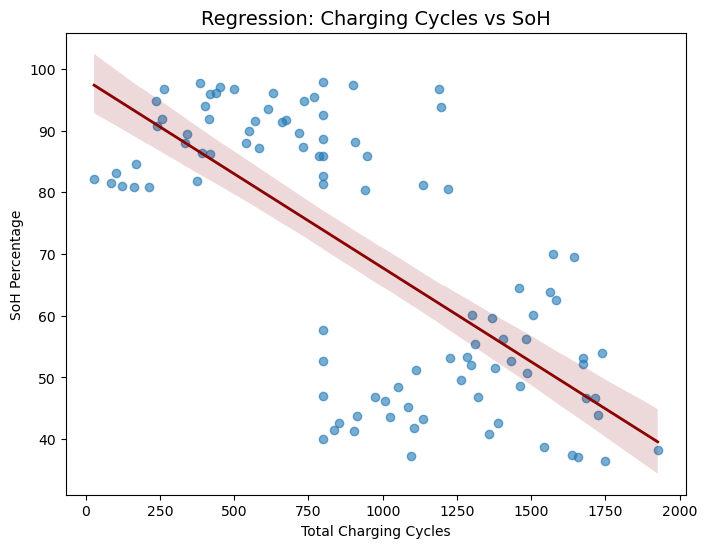

In [37]:
import seaborn as sns

plt.figure(figsize=(8,6))

sns.regplot(
    x="Total_Charging_Cycles",
    y="SoH_Percent",
    data=df.head(100),
    scatter_kws={"alpha":0.6},
    line_kws={"color":"darkred", "linewidth":2}
)

plt.title("Regression: Charging Cycles vs SoH", fontsize=14)
plt.xlabel("Total Charging Cycles")
plt.ylabel("SoH Percentage")
plt.show()



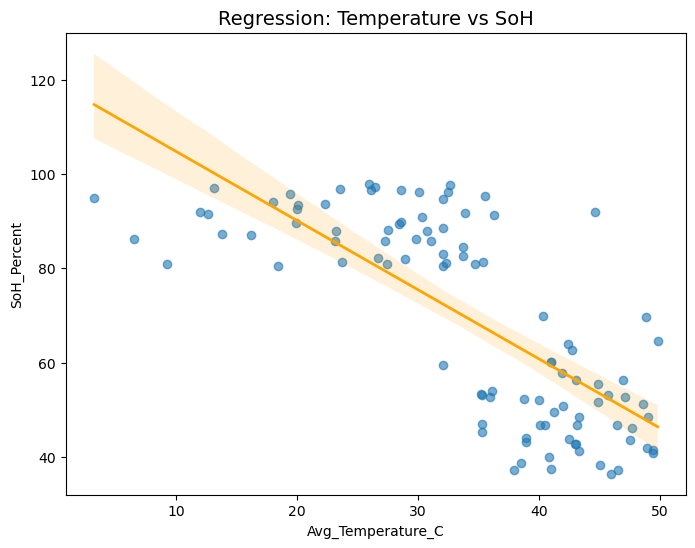

In [38]:
plt.figure(figsize=(8,6))

sns.regplot(
    x="Avg_Temperature_C",
    y="SoH_Percent",
    data=df.head(100),
    scatter_kws={"alpha":0.6},
    line_kws={"color":"orange", "linewidth":2}
)

plt.title("Regression: Temperature vs SoH", fontsize=14)
plt.show()

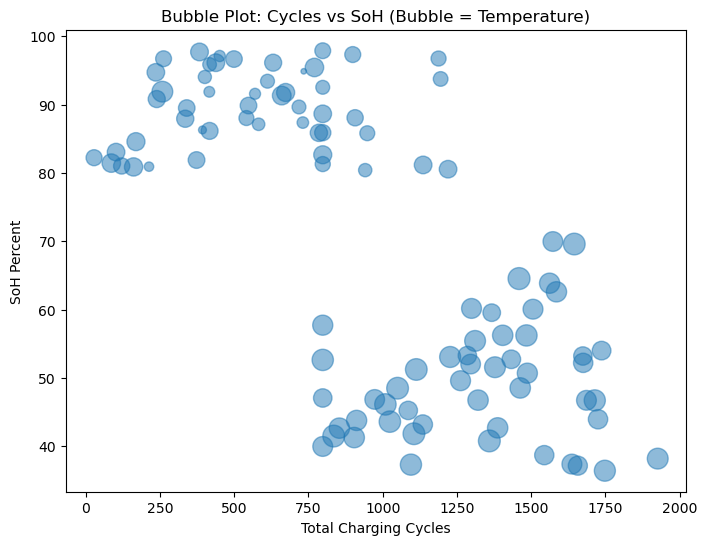

In [ ]:
plt.figure(figsize=(8,6))

plt.scatter(
    df["Total_Charging_Cycles"].head(100),
    df["SoH_Percent"].head(100),
    s=df["Avg_Temperature_C"].head(100) * 5,   
    alpha=0.5
)

plt.xlabel("Total Charging Cycles")
plt.ylabel("SoH Percent")
plt.title("Bubble Plot: Cycles vs SoH (Bubble = Temperature)")
plt.show()

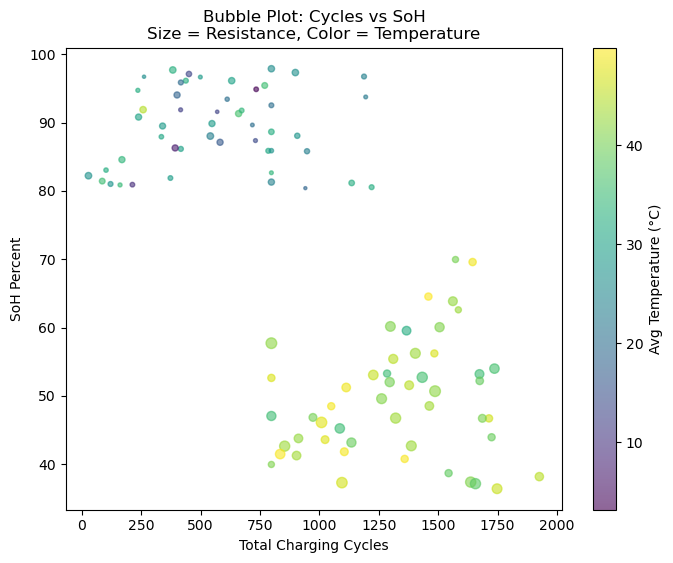

In [40]:
plt.figure(figsize=(8,6))

scatter = plt.scatter(
    df["Total_Charging_Cycles"].head(100),
    df["SoH_Percent"].head(100),
    s=df["Internal_Resistance_Ohm"].head(100) * 500,
    c=df["Avg_Temperature_C"].head(100),
    cmap="viridis",
    alpha=0.6
)

plt.colorbar(scatter, label="Avg Temperature (°C)")
plt.xlabel("Total Charging Cycles")
plt.ylabel("SoH Percent")
plt.title("Bubble Plot: Cycles vs SoH\nSize = Resistance, Color = Temperature")

plt.show()